# 05. Future Nutrition Condition Prediction

This notebook builds a clean machine learning pipeline to predict a child's **future nutrition condition** using current and previous visit information.

The model supports a user-defined prediction horizon, such as **1 month**, **3 months**, **6 months**, or **12 months**, using the `Month_Gap` feature.

## Goal

```text
Current Visit Information
        ↓
Prediction Horizon
        ↓
Predicted Future Condition
        ↓
Probability + Recommendation
```

## 1. Import Required Libraries

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load Dataset

Input file:

```text
data/trend_ready_data.csv
```

This file contains all visit-level records and is suitable for future prediction model training.

In [2]:
# Flexible path support for both project root and modules folder
possible_paths = [
    "../data/trend_ready_data.csv",
    "data/trend_ready_data.csv",
    "/mnt/data/trend_ready_data.csv"
]

DATA_PATH = None
for path in possible_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError("trend_ready_data.csv not found. Please check data folder path.")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Dataset loaded successfully
Shape: (5080, 9)
Columns: ['ID', 'GmpDate', 'Name', 'DOB', 'MUAC', 'Age_Months', 'Condition', 'Cluster', 'Cluster_Name']


,ID,GmpDate,Name,DOB,MUAC,Age_Months,Condition,Cluster,Cluster_Name
0,581415010001,2017-12-17,ff,2017-12-17,15.0,0.00,Good,0,Healthy
1,581415010001,2017-12-28,ff,2017-12-17,15.0,0.36,Good,0,Healthy
2,581415010002,2017-12-17,gg,2017-12-17,13.0,0.00,At Risk,1,Moderate Risk
3,581415010002,2017-12-28,gg,2017-12-17,14.0,0.36,Good,1,Moderate Risk
4,581415010004,2017-12-18,hskkd,2017-12-18,13.0,0.00,At Risk,1,Moderate Risk


## 3. Prepare Date and Sort Visit Records

The data must be sorted by child ID and visit date so that previous and future visit information can be generated correctly.

In [3]:
df["GmpDate"] = pd.to_datetime(df["GmpDate"], errors="coerce")

df = df.dropna(subset=["ID", "GmpDate", "MUAC", "Age_Months", "Condition", "Cluster"])

df = df.sort_values(["ID", "GmpDate"]).reset_index(drop=True)

print("Data sorted by ID and GmpDate")
df.head()

Data sorted by ID and GmpDate


,ID,GmpDate,Name,DOB,MUAC,Age_Months,Condition,Cluster,Cluster_Name
0,581415010001,2017-12-17,ff,2017-12-17,15.0,0.00,Good,0,Healthy
1,581415010001,2017-12-28,ff,2017-12-17,15.0,0.36,Good,0,Healthy
2,581415010002,2017-12-17,gg,2017-12-17,13.0,0.00,At Risk,1,Moderate Risk
3,581415010002,2017-12-28,gg,2017-12-17,14.0,0.36,Good,1,Moderate Risk
4,581415010004,2017-12-18,hskkd,2017-12-18,13.0,0.00,At Risk,1,Moderate Risk


## 4. Feature Engineering

The model uses both current and previous visit information.

Created columns:

- `Visit_Number`: visit sequence of each child
- `Previous_MUAC`: MUAC from previous visit
- `MUAC_Change`: current MUAC minus previous MUAC
- `Month_Gap`: time gap between current and previous visit in months
- `Next_Condition`: future condition from next available visit

In [4]:
# Visit number for each child
df["Visit_Number"] = df.groupby("ID").cumcount() + 1

# Previous visit information
df["Previous_MUAC"] = df.groupby("ID")["MUAC"].shift(1)
df["Previous_Date"] = df.groupby("ID")["GmpDate"].shift(1)

# MUAC change
df["MUAC_Change"] = df["MUAC"] - df["Previous_MUAC"]

# Month gap between current and previous visit
df["Month_Gap"] = (df["GmpDate"] - df["Previous_Date"]).dt.days / 30

# Future target: next observed condition
df["Next_Condition"] = df.groupby("ID")["Condition"].shift(-1)

# Clean rows where previous information or target is missing
model_df = df.dropna(
    subset=["Previous_MUAC", "MUAC_Change", "Month_Gap", "Next_Condition"]
).copy()

print("Model-ready data shape:", model_df.shape)
model_df[[
    "ID", "GmpDate", "Visit_Number", "MUAC", "Previous_MUAC", "MUAC_Change", 
    "Month_Gap", "Condition", "Next_Condition"
]].head(10)

Model-ready data shape: (2408, 15)


,ID,GmpDate,Visit_Number,MUAC,Previous_MUAC,MUAC_Change,Month_Gap,Condition,Next_Condition
11,581494010014,2017-08-27,2,15.0,15.0,0.0,1.033333,Good,Good
28,581494080257,2017-12-24,2,13.8,14.0,-0.2,0.100000,Good,At Risk
33,581494080400,2017-12-24,2,13.0,13.0,0.0,0.133333,At Risk,Good
38,583547010005,2017-12-27,2,12.0,12.0,0.0,0.333333,Moderate,Severe
65,583547140005,2018-02-12,2,14.0,13.0,1.0,1.166667,Good,Good
66,583547140005,2018-05-14,3,14.0,14.0,0.0,3.033333,Good,Good
69,583547140039,2018-02-12,2,14.0,13.0,1.0,1.166667,Good,Good
70,583547140039,2018-03-17,3,14.4,14.0,0.4,1.100000,Good,Good
71,583547140039,2018-04-16,4,15.0,14.4,0.6,1.000000,Good,Good
74,583547140048,2018-02-12,2,13.0,13.0,0.0,1.166667,At Risk,At Risk


## 5. Check Prediction Horizon Distribution

This shows how many months usually pass between two child monitoring visits.

The dataset mainly contains monthly GMP visits, but longer gaps also exist. Therefore, `Month_Gap` is included as a model feature.

In [5]:
model_df["Month_Gap"].describe()

count    2408.000000
mean        1.521429
std         1.535244
min         0.033333
25%         0.933333
50%         1.000000
75%         1.808333
max        17.200000
Name: Month_Gap, dtype: float64

## 6. Encode Categorical Labels

Random Forest requires numeric features, so the current and target conditions are encoded.

In [6]:
condition_encoder = LabelEncoder()
target_encoder = LabelEncoder()

model_df["Condition_Enc"] = condition_encoder.fit_transform(model_df["Condition"])
model_df["Next_Condition_Enc"] = target_encoder.fit_transform(model_df["Next_Condition"])

print("Current condition classes:", list(condition_encoder.classes_))
print("Target condition classes:", list(target_encoder.classes_))

Current condition classes: ['At Risk', 'Good', 'Moderate', 'Severe']
Target condition classes: ['At Risk', 'Good', 'Moderate', 'Severe']


## 7. Select Features and Target

Input features:

```text
MUAC
Age_Months
Visit_Number
Cluster
Previous_MUAC
MUAC_Change
Condition_Enc
Month_Gap
```

Target:

```text
Next_Condition_Enc
```

In [7]:
features = [
    "MUAC",
    "Age_Months",
    "Visit_Number",
    "Cluster",
    "Previous_MUAC",
    "MUAC_Change",
    "Condition_Enc",
    "Month_Gap"
]

X = model_df[features]
y = model_df["Next_Condition_Enc"]
groups = model_df["ID"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Features:", features)

Feature shape: (2408, 8)
Target shape: (2408,)
Features: ['MUAC', 'Age_Months', 'Visit_Number', 'Cluster', 'Previous_MUAC', 'MUAC_Change', 'Condition_Enc', 'Month_Gap']


## 8. Train/Test Split Using Child Groups

A group-based split is used so that the same child's visits do not appear in both training and testing data.

This prevents data leakage and makes evaluation more realistic.

In [8]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training children:", model_df.iloc[train_idx]["ID"].nunique())
print("Testing children:", model_df.iloc[test_idx]["ID"].nunique())

Training data: (1967, 8)
Testing data: (441, 8)
Training children: 632
Testing children: 158


## 9. Train Random Forest Classifier

Random Forest is used because this is a multi-class classification problem:

```text
Good / At Risk / Moderate / Severe
```

Why Random Forest?

- Works well with tabular data
- Handles non-linear relationships
- Robust to noise
- Provides prediction probabilities
- Provides feature importance

In [9]:
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=20,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


## 10. Model Evaluation

In [10]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 76.42 %


## 11. Classification Report

This shows precision, recall, and F1-score for each nutrition condition.

In [11]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

     At Risk       0.57      0.48      0.52       105
        Good       0.84      0.91      0.87       304
    Moderate       0.29      0.21      0.24        19
      Severe       0.62      0.38      0.48        13

    accuracy                           0.76       441
   macro avg       0.58      0.50      0.53       441
weighted avg       0.74      0.76      0.75       441



## 12. Confusion Matrix

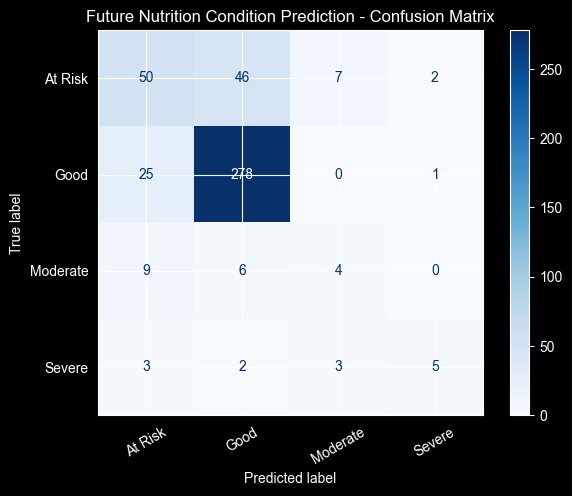

In [12]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Future Nutrition Condition Prediction - Confusion Matrix")
plt.xticks(rotation=30)
plt.show()

## 13. Feature Importance

This shows which variables influenced the model most.

In [13]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
1,Age_Months,0.203462
0,MUAC,0.172537
4,Previous_MUAC,0.149545
7,Month_Gap,0.146209
5,MUAC_Change,0.124456
2,Visit_Number,0.080486
6,Condition_Enc,0.078252
3,Cluster,0.045053


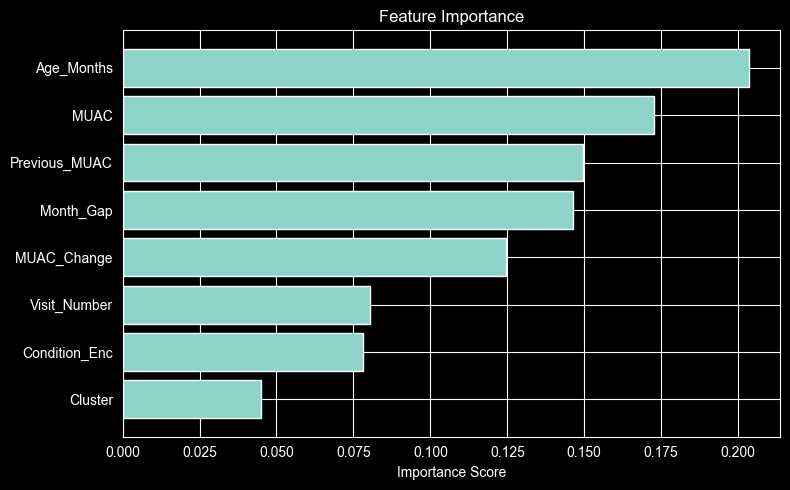

In [14]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## 14. Helper Function: Recommendation

This function creates a practical recommendation based on predicted future condition.

In [15]:
def get_recommendation(pred_condition):
    if pred_condition == "Good":
        return ("✅ Child is likely to remain or improve nutritionally.""• Continue regular growth monitoring.""• Maintain healthy feeding practices.""• Attend scheduled GMP visits."
        )

    if pred_condition == "At Risk":
        return ("⚠️ Child may become nutritionally at risk.""• Regular follow-up is recommended.""• Provide nutrition counseling to caregiver.""• Monitor MUAC closely."
        )

    if pred_condition == "Moderate":
        return ("🟠 Moderate nutrition risk predicted.""• Nutritional support is recommended.""• Increase monitoring frequency.""• Consult health worker if condition continues."
        )

    return (
        "🔴 Severe nutrition risk predicted.""• Immediate nutrition intervention is recommended.""• Refer to health worker or nutrition support program.""• Follow up urgently."
    )

## 15. User Input Prediction Function

This function predicts future nutrition condition using manual input.

It does not require child ID or child name, so it can be used for any child.

In [16]:
# Manually enter child ID
child_id = 581494080247

child_info = df[df["ID"] == child_id].sort_values("GmpDate")

show_columns = [
    "ID",
    "GmpDate",
    "Name",
    "DOB",
    "Age_Months",
    "MUAC",
    "Condition",
    "Cluster",
    "Cluster_Name",
    "Visit_Number",
    "Previous_MUAC",
    "MUAC_Change",
    "Month_Gap",
    "Next_Condition"
]

show_columns = [col for col in show_columns if col in df.columns]

if len(child_info) == 0:
    print("No records found for this child ID")
else:
    display(child_info[show_columns])

,ID,GmpDate,Name,DOB,Age_Months,MUAC,Condition,Cluster,Cluster_Name,Visit_Number,Previous_MUAC,MUAC_Change,Month_Gap,Next_Condition
19,581494080247,2017-12-06,shahim begum,2016-08-05,16.03,14.5,Good,1,Moderate Risk,1,NaN,NaN,NaN,Good
20,581494080247,2017-12-24,shahim begum,2016-08-05,16.62,14.5,Good,1,Moderate Risk,2,14.5,0.0,0.6,NaN


In [17]:
def predict_future_condition(
    current_muac,
    previous_muac,
    age_months,
    visit_number,
    cluster,
    current_condition,
    prediction_horizon_months
):
    """
    Predict future nutrition condition for a child using current visit information.
    """

    if current_condition not in condition_encoder.classes_:
        raise ValueError(
            f"Invalid current_condition: {current_condition}. "
            f"Allowed values: {list(condition_encoder.classes_)}"
        )

    muac_change = current_muac - previous_muac
    condition_enc = condition_encoder.transform([current_condition])[0]

    input_data = pd.DataFrame([{
        "MUAC": current_muac,
        "Age_Months": age_months,
        "Visit_Number": visit_number,
        "Cluster": cluster,
        "Previous_MUAC": previous_muac,
        "MUAC_Change": muac_change,
        "Condition_Enc": condition_enc,
        "Month_Gap": prediction_horizon_months
    }])

    prediction_enc = rf.predict(input_data)[0]
    probabilities = rf.predict_proba(input_data)[0]

    predicted_condition = target_encoder.inverse_transform([prediction_enc])[0]
    confidence = probabilities[prediction_enc] * 100

    print("🔮 Future Nutrition Prediction Result")
    print("--------------------------------------------------")
    print("Current Visit Information")
    print(f"Current MUAC: {current_muac:.2f} cm")
    print(f"Previous MUAC: {previous_muac:.2f} cm")
    print(f"MUAC Change: {muac_change:.2f} cm")
    print(f"Age: {age_months} months")
    print(f"Visit Number: {visit_number}")
    print(f"Current Condition: {current_condition}")
    print("--------------------------------------------------")
    print(f"Prediction Horizon: {prediction_horizon_months} Months")
    print(f"Predicted Future Condition: {predicted_condition}")
    print(f"Confidence: {confidence:.2f}%")
    print("--------------------------------------------------")
    print("Prediction Probability:")

    for condition, prob in zip(target_encoder.classes_, probabilities):
        print(f"{condition:<9}: {prob * 100:.2f}%")

    print("--------------------------------------------------")
    print("Recommendation:")
    print(get_recommendation(predicted_condition))

    return {
        "predicted_condition": predicted_condition,
        "confidence": confidence,
        "probabilities": dict(zip(target_encoder.classes_, probabilities))
    }

## 16. Example Prediction

This example predicts future nutrition condition for a child using manual input values.

In [18]:
result = predict_future_condition(
    current_muac=14.5,
    previous_muac=14.5,
    age_months=16.32,
    visit_number=2,
    cluster=1,
    current_condition="Good",
    prediction_horizon_months=6
)

🔮 Future Nutrition Prediction Result
--------------------------------------------------
Current Visit Information
Current MUAC: 14.50 cm
Previous MUAC: 14.50 cm
MUAC Change: 0.00 cm
Age: 16.32 months
Visit Number: 2
Current Condition: Good
--------------------------------------------------
Prediction Horizon: 6 Months
Predicted Future Condition: Good
Confidence: 90.11%
--------------------------------------------------
Prediction Probability:
At Risk  : 3.59%
Good     : 90.11%
Moderate : 0.00%
Severe   : 6.30%
--------------------------------------------------
Recommendation:
✅ Child is likely to remain or improve nutritionally.• Continue regular growth monitoring.• Maintain healthy feeding practices.• Attend scheduled GMP visits.


## 17. Compare Different Prediction Horizons

This helps verify whether prediction changes when the horizon changes.

In [19]:
for horizon in [1, 3, 6, 12]:
    print("")
    print("=" * 70)
    result = predict_future_condition(
        current_muac=12.8,
        previous_muac=12.2,
        age_months=24,
        visit_number=4,
        cluster=1,
        current_condition="At Risk",
        prediction_horizon_months=horizon
    )


🔮 Future Nutrition Prediction Result
--------------------------------------------------
Current Visit Information
Current MUAC: 12.80 cm
Previous MUAC: 12.20 cm
MUAC Change: 0.60 cm
Age: 24 months
Visit Number: 4
Current Condition: At Risk
--------------------------------------------------
Prediction Horizon: 1 Months
Predicted Future Condition: At Risk
Confidence: 51.26%
--------------------------------------------------
Prediction Probability:
At Risk  : 51.26%
Good     : 35.24%
Moderate : 12.80%
Severe   : 0.70%
--------------------------------------------------
Recommendation:
⚠️ Child may become nutritionally at risk.• Regular follow-up is recommended.• Provide nutrition counseling to caregiver.• Monitor MUAC closely.

🔮 Future Nutrition Prediction Result
--------------------------------------------------
Current Visit Information
Current MUAC: 12.80 cm
Previous MUAC: 12.20 cm
MUAC Change: 0.60 cm
Age: 24 months
Visit Number: 4
Current Condition: At Risk
-------------------------

## 18. Save Model and GUI-Ready Files

These files will be used later in the GUI application.

In [20]:
# Flexible output folders
possible_model_dirs = ["../models", "models"]
possible_data_dirs = ["../data", "data"]

MODEL_DIR = possible_model_dirs[0] if os.path.exists(os.path.dirname(possible_model_dirs[0])) else possible_model_dirs[1]
DATA_DIR = possible_data_dirs[0] if os.path.exists(os.path.dirname(possible_data_dirs[0])) else possible_data_dirs[1]

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

joblib.dump(rf, os.path.join(MODEL_DIR, "future_condition_model.pkl"))
joblib.dump(condition_encoder, os.path.join(MODEL_DIR, "condition_encoder.pkl"))
joblib.dump(target_encoder, os.path.join(MODEL_DIR, "target_encoder.pkl"))
joblib.dump(features, os.path.join(MODEL_DIR, "future_condition_features.pkl"))

model_df.to_csv(os.path.join(DATA_DIR, "final_prediction_dataset.csv"), index=False)

print("Model and GUI-ready dataset saved successfully")
print("Model folder:", MODEL_DIR)
print("Data folder:", DATA_DIR)

Model and GUI-ready dataset saved successfully
Model folder: ../models
Data folder: ../data
